In [27]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import boxcox
from statsmodels.stats.anova import anova_lm

In [28]:
#Load model-ready data
df = pd.read_csv("kidney_disease_model_ready.csv")

# Define response variable
y = np.log1p(df["sc"])  # serum creatinine

#Build full predictor matrix drop response
X_full = df.drop(columns=["sc"])

#Add intercept and fit FULL model
X_full_const = sm.add_constant(X_full)
log_model = sm.OLS(y, X_full_const).fit()

print(log_model.summary())
params = log_model.params  
equation = "sc_hat = "




                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     46.24
Date:                Sat, 29 Nov 2025   Prob (F-statistic):           1.62e-52
Time:                        15:34:59   Log-Likelihood:                 30.645
No. Observations:                 158   AIC:                            -13.29
Df Residuals:                     134   BIC:                             60.21
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.3551      5.657     -0.593      

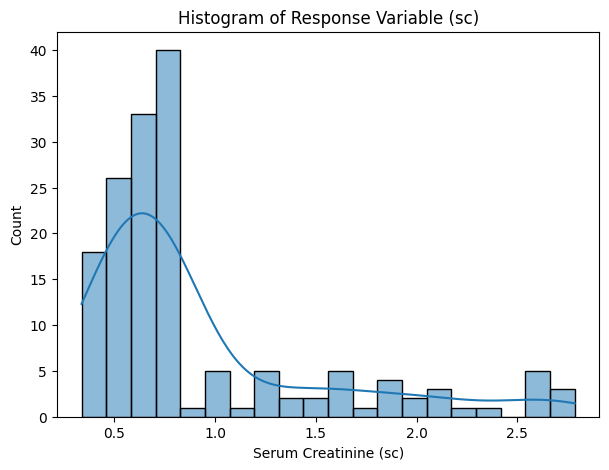

In [29]:
# Histogram of serum creatinine (sc)
plt.figure(figsize=(7,5))
sns.histplot(y, kde=True, bins=20)
plt.xlabel("Serum Creatinine (sc)")
plt.title("Histogram of Response Variable (sc)")
plt.show()

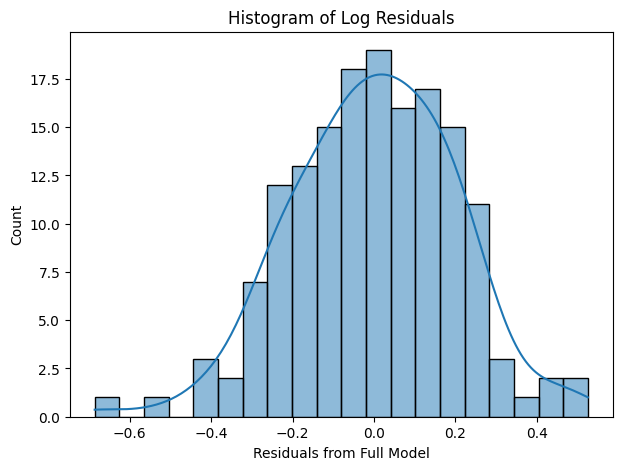

In [30]:
# Log residuals of full model
resid_full = log_model.resid

plt.figure(figsize=(7,5))
sns.histplot(resid_full, kde=True, bins=20)
plt.xlabel("Residuals from Full Model")
plt.title("Histogram of Log Residuals")
plt.show()

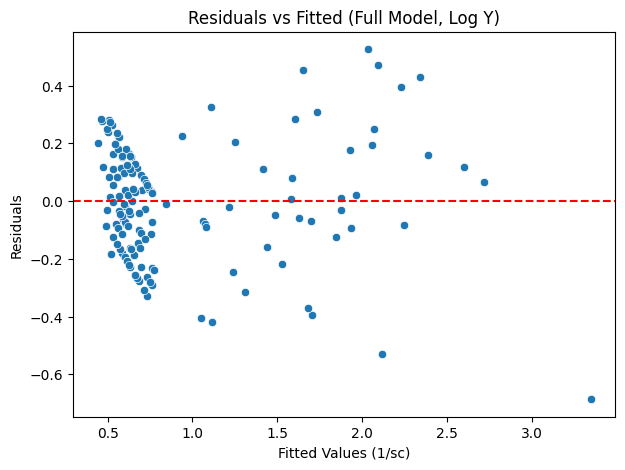

In [31]:
fitted_vals = log_model.fittedvalues
residuals = log_model.resid

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Full Model, Log Y)")
plt.show()

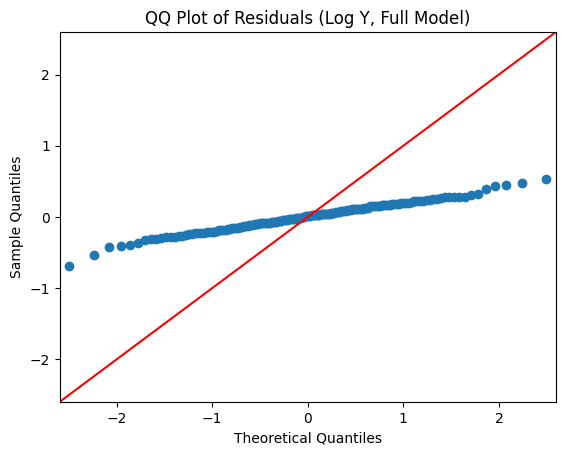

In [32]:
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals (Log Y, Full Model)")
plt.show()


In [33]:
#VIF on reduced
X_full_const = sm.add_constant(X_full)
vif_data = pd.DataFrame()
vif_data["feature"] = X_full_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_full_const.values, i)
                   for i in range(X_full_const.shape[1])]

print(vif_data)

        feature            VIF
0         const  107932.677571
1           age       1.270614
2            bp       1.473606
3            sg       3.220942
4            al       5.747374
5            su       3.464760
6           bgr       3.590615
7            bu       3.178348
8           sod       2.139629
9           pot       1.626929
10         hemo       5.394035
11          pcv       5.495848
12           wc       1.489172
13           rc       2.895132
14   rbc_normal       2.430211
15    pc_normal       4.239018
16  pcc_present       2.365934
17   ba_present       2.182825
18      htn_yes       5.715146
19       dm_yes       5.142223
20      cad_yes       1.933202
21   appet_poor       2.752290
22       pe_yes       3.800977
23      ane_yes       3.350359


In [34]:
alpha = 0.10 

X_current = X_full.copy()
removed_vars = []
step = 0

while True:
    X_const = sm.add_constant(X_current)
    model = sm.OLS(y, X_const).fit()

    # p-values for all predictors except the intercept
    pvals = model.pvalues.drop("const")
    worst_p = pvals.max()
    worst_var = pvals.idxmax()

    print(f"Step {step}: max p-value = {worst_p:.4f} for variable '{worst_var}'")

    # stop if all remaining variables are significant at alpha
    if worst_p < alpha:
        print("\nAll remaining variables have p-values < alpha.")
        break
    # otherwise drop the worst variable and continue
    removed_vars.append((worst_var, worst_p))
    X_current = X_current.drop(columns=[worst_var])
    step += 1

print("\nVariables removed (in order):")
for var, p in removed_vars:
    print(f"  {var}: p = {p:.4f}")

print("\nFinal predictor set:")
print(list(X_current.columns))



Step 0: max p-value = 0.9394 for variable 'dm_yes'
Step 1: max p-value = 0.9191 for variable 'cad_yes'
Step 2: max p-value = 0.8928 for variable 'bgr'
Step 3: max p-value = 0.9396 for variable 'su'
Step 4: max p-value = 0.6880 for variable 'rc'
Step 5: max p-value = 0.6752 for variable 'ba_present'
Step 6: max p-value = 0.6396 for variable 'age'
Step 7: max p-value = 0.6034 for variable 'pcc_present'
Step 8: max p-value = 0.5978 for variable 'hemo'
Step 9: max p-value = 0.4190 for variable 'sod'
Step 10: max p-value = 0.3907 for variable 'sg'
Step 11: max p-value = 0.2939 for variable 'pc_normal'
Step 12: max p-value = 0.3016 for variable 'ane_yes'
Step 13: max p-value = 0.3210 for variable 'rbc_normal'
Step 14: max p-value = 0.2420 for variable 'appet_poor'
Step 15: max p-value = 0.1003 for variable 'wc'
Step 16: max p-value = 0.2102 for variable 'pcv'
Step 17: max p-value = 0.0874 for variable 'pot'

All remaining variables have p-values < alpha.

Variables removed (in order):
  dm_y

In [44]:
X_reduced_const = sm.add_constant(X_current)
reduced_model = sm.OLS(y, X_reduced_const).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     182.9
Date:                Sat, 29 Nov 2025   Prob (F-statistic):           1.24e-66
Time:                        15:38:38   Log-Likelihood:                 24.518
No. Observations:                 158   AIC:                            -35.04
Df Residuals:                     151   BIC:                            -13.60
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0624      0.120      0.520      0.6

In [46]:
X_full_const = sm.add_constant(X_full)
full_model_trans = sm.OLS(y, X_full_const).fit()

reduced_predictors = ['bp', 'al', 'bu', 'pot', 'htn_yes', 'pe_yes']
X_reduced = X_full[reduced_predictors]
X_reduced_const = sm.add_constant(X_reduced)
reduced_model_trans = sm.OLS(y, X_reduced_const).fit()

resid = reduced_model_trans.resid
fitted = reduced_model_trans.fittedvalues

anova_results = anova_lm(reduced_model_trans, full_model_trans)

print(anova_results)

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     151.0  6.782645      0.0       NaN       NaN       NaN
1     134.0  6.276461     17.0  0.506185  0.635697  0.858398


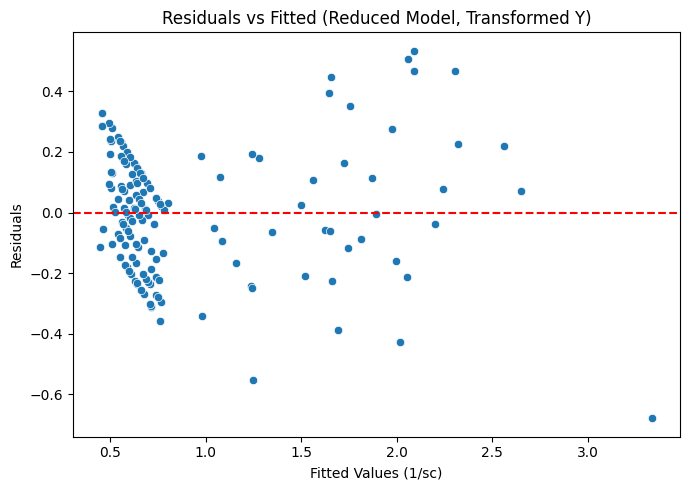

In [47]:
#Residuals vs Fitted Values Plots
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Reduced Model, Transformed Y)")
plt.tight_layout()
plt.show()

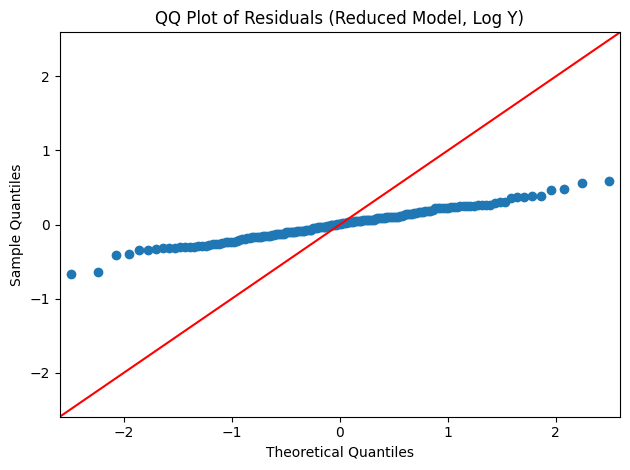

In [39]:
# QQ Plot
sm.qqplot(resid, line="45")
plt.title("QQ Plot of Residuals (Reduced Model, Log Y)")
plt.tight_layout()
plt.show()

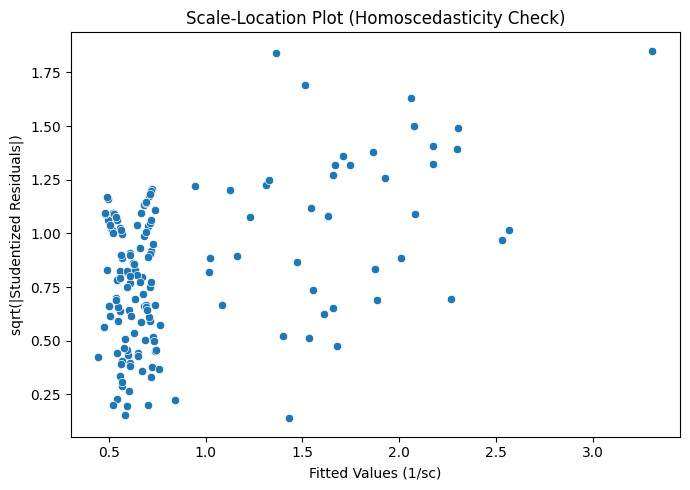

In [40]:
# Scale location plot
plt.figure(figsize=(7,5))
sqrt_abs_sr = np.sqrt(np.abs(studentized_resid))
sns.scatterplot(x=fitted, y=sqrt_abs_sr)
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("sqrt(|Studentized Residuals|)")
plt.title("Scale-Location Plot (Homoscedasticity Check)")
plt.tight_layout()
plt.show()

In [41]:
#cooks distance
plt.figure(figsize=(7,5))
plt.stem(np.arange(n), cooks_d)
plt.axhline(4/n, color="red", linestyle="--", label="4/n threshold")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'n' is not defined

<Figure size 700x500 with 0 Axes>